In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp
import jax
import jax.numpy as jnp
from jax.example_libraries import optimizers
from jax import random, grad, jit, vmap
from functools import partial

from diffrax import diffeqsolve, ODETerm, Kvaerno5, SaveAt, PIDController, Kvaerno3, Tsit5, BacksolveAdjoint 
from CoolProp.CoolProp import PropsSI
jax.config.update("jax_enable_x64", True)


In [2]:
# Import polyfit function from CoolProp
folder   = '../Cryoevap/cryogens/Coeffs/'
cp_V_df  = pd.read_csv(folder + 'coeffs_cpV.csv')
k_V_df   = pd.read_csv(folder + 'coeffs_kV.csv')
rho_V_df = pd.read_csv(folder + 'coeffs_rhoV.csv')

k_V_df

,Unnamed: 0,ammonia,hydrogen,methane,nitrogen
0,x^4,-4.598511e-13,6.350522e-12,-7.987907e-13,-3.046396e-14
1,x^3,1.344802e-10,-6.092023e-09,1.175846e-09,9.058631e-11
2,x^2,4.748340e-07,1.520495e-06,-4.701132e-07,-1.073373e-07
3,x^1,-1.805246e-04,5.240556e-04,1.900175e-04,1.153373e-04
4,x^0,3.661632e-02,5.790916e-03,-5.568751e-03,-1.171207e-03


In [ ]:
class Cryogen:
    def __init__(self, fluid='ammonia', P=100000):
        self.fluid = fluid
        self.P = float(P)
        self.T_sat = jnp.array(PropsSI('T', 'P', P, 'Q', 0, fluid), dtype=jnp.float64)
        self.h_L   = jnp.array(PropsSI('H', 'P', P, 'Q', 0, fluid), dtype=jnp.float64)
        self.h_V   = jnp.array(PropsSI('H', 'P', P, 'Q', 1, fluid), dtype=jnp.float64)
        self.rho_L = jnp.array(PropsSI('D', 'P', P, 'Q', 0, fluid), dtype=jnp.float64)

class Tank:
    def __init__(self, d_i, d_o, V, LF=0.95, cryogen=None):
        self.d_i           = jnp.array(d_i, dtype=jnp.float64)
        self.d_o           = jnp.array(d_o, dtype=jnp.float64)
        self.V             = jnp.array(V, dtype=jnp.float64)
        self.LF            = jnp.array(LF, dtype=jnp.float64)
        self.cryogen       = cryogen or Cryogen()
        self.z_grid        = jnp.linspace(0, 1, 25, dtype=jnp.float64)
        self.time_interval = 1800.0
        self.U_L           = jnp.array(0.08, dtype=jnp.float64)
        self.U_V           = jnp.array(0.08, dtype=jnp.float64)
        self.T_air         = jnp.array(298.15, dtype=jnp.float64)
        self.Q_b_fixed     = None
        self.Q_roof        = 0.0
        self.eta_w         = jnp.array(0.9, dtype=jnp.float64)

    def A_T(self):
        return jnp.pi * self.d_i ** 2 / 4

    def l(self):
        return self.V / self.A_T()

def make_params(tank):
    cryo = tank.cryogen
    return {
        "V":      tank.V,
        "d_i":    tank.d_i,
        "d_o":    tank.d_o,
        "LF":     tank.LF,
        "eta_w":  tank.eta_w,
        "T_air":  tank.T_air,
        "U_L":    tank.U_L,
        "U_V":    tank.U_V,
        "dz":     0.1,
        "z_grid": tank.z_grid,
        "T_sat":  cryo.T_sat,
        "h_L":    cryo.h_L,
        "h_V":    cryo.h_V,
        "rho_L":  cryo.rho_L,
        'time_interval': tank.time_interval,
        "cp_V_poly": jnp.array(cp_V_df[cryo.fluid].values, dtype=jnp.float64),
        "k_V_poly": jnp.array(k_V_df[cryo.fluid].values, dtype=jnp.float64),
        "rho_V_poly": jnp.array(rho_V_df[cryo.fluid].values, dtype=jnp.float64)
    }

@jax.jit
def cp_V_fun(T, p):
    """Calculate the specific heat capacity of the vapour."""
    powers_matrix = jnp.vstack([T**6, T**5, T**4, T**3, T**2, T, jnp.ones_like(T)])
    return jnp.dot(p, powers_matrix)

@jax.jit
def k_V_fun(T, p):
    """Calculate the thermal conductivity of the vapour."""
    powers_matrix = jnp.vstack([T**4, T**3, T**2, T, jnp.ones_like(T)])
    return jnp.dot(p, powers_matrix)

@jax.jit
def rho_V_fun(T, p):
    """Calculate the density of the vapour."""
    powers_matrix = jnp.vstack([T**4, T**3, T**2, T, jnp.ones_like(T)])
    return jnp.dot(p, powers_matrix)

@jax.jit
def sys_isobaric_jax(t, y, args):
    aspect_ratio, p = args
    d_i = ((4 * p["V"])/(jnp.pi * aspect_ratio))**(1/3)
    d_o = d_i + 0.02 


    # Unpack variables
    V_L   = y[0]
    T_V   = y[1:]

    # Calculate parameters
    A_T   = jnp.pi * d_i ** 2 / 4
    l     = p["V"] / A_T
    l_dry = l * (1 - p['LF'])
    dz    = p["dz"] * l_dry

    z_grid = jnp.linspace(0, 1, 1 + int(jnp.round(l_dry/['dz'], 0)))


    # Calculate vapour properties
    k_V   = jnp.mean(k_V_fun(T_V, p["k_V_poly"]))
    cp_V  = jnp.mean(cp_V_fun(T_V, p["cp_V_poly"]))
    rho_V = jnp.mean(rho_V_fun(T_V, p["rho_V_poly"]))

    # Areas
    A_V = jnp.pi * d_o * l * (1 - p['LF'])
    A_L = jnp.pi * d_o * l * p['LF']

    # Heat transfer calculations
    Q_Lin = p["U_L"] * A_L * (p["T_air"] - p["T_sat"])
    Q_VL  = k_V * A_T * (-3 * T_V[0] + 4 * T_V[1] - T_V[2]) / (2 * dz)
    Q_b   = p["U_L"] * A_T * (p["T_air"] - p["T_sat"])
    Q_wi  = p["U_V"] * A_V * p["eta_w"] * (p["T_air"] - jnp.mean(T_V))

    # Initial evaporation rate Kg/s
    BL_0 = (Q_Lin + Q_b + Q_wi) / (p["h_V"] - p["h_L"])
    
    # Advective and interface velocity
    v_z   = 4 * BL_0 / (rho_V  * jnp.pi * d_i ** 2)
    v_int = v_z * (rho_V  / p["rho_L"])

    # Vapour thermal diffusivity
    alpha = k_V / (rho_V  * cp_V)

    # Initialize derivatives
    dT = jnp.zeros_like(T_V)

    # Calculate space derivatives
    dT_dz   = (T_V[1:-1] - T_V[:-2]) / dz
    d2T_dz2 = (T_V[:-2] - 2 * T_V[1:-1] + T_V[2:]) / (dz ** 2)
    
    # Wall heating considering the wall heat partitioning.
    S_wall  = (4 * p["U_V"] * d_o / (d_i ** 2)) * (p["T_air"] - T_V[1:-1]) * (1 - p["eta_w"])

    # Update temperature derivatives
    dT = dT.at[1:-1].set(
        alpha * d2T_dz2 - (v_z - v_int) * dT_dz + (alpha/ k_V) * S_wall
    )

    # Boundary conditions
    dT = dT.at[0].set(0.0)
    dT = dT.at[-1].set((4 * dT[-2] - dT[-3]) / 3) # Neumann condition by default

    # Volume derivative
    dV = (-1 / p["rho_L"]) * (Q_Lin + Q_b + Q_wi + Q_VL) / (p["h_V"] - p["h_L"])

    return jnp.concatenate([jnp.array([dV], dtype=jnp.float64), dT])

def BOR(V_L, t):
    """
    Calculates the Boil-Off Rate (BOR) as the percentage of the initial liquid volume that evaporates per day during storage.
    """
    return (1.0 - V_L[-1] / V_L[0]) * (86400.0 / t[-1])

def objective_function(aspect_ratio, t_f, p):
    """
    Objective function to minimize the Boil-Off Rate (BOR) of the cryogenic tank.
    """
    a_effective = jnp.array(0.1 + jnp.exp(aspect_ratio))
    sol = evaporate(p, t_f, a_effective)
    V_L = sol.ys[:, 0]
    t   = sol.ts
    return BOR(V_L, t)

def optimize_tank(opt_state, tank_params, t_f, max_iter, lr):
    """
    Optimize the tank parameters to minimize the Boil-Off Rate (BOR).
    This function can be extended to include optimization algorithms.
    """
    train_loss = []
    opt_init, opt_update, get_params = optimizers.adam(lr)
    params    = get_params(opt_state)

    for i in range(max_iter):
        # Compute the objective function
        params = get_params(opt_state) 
        grads     = grad(objective_function)(params, t_f, tank_params)
        opt_state = opt_update(i, grads, opt_state)
        loss_val = objective_function(params, t_f, tank_params)
        train_loss.append(loss_val)
        print(f"Iteration {i}, Training loss: {loss_val:.4e}, lr: {lr:.4e}, aspect_ratio: {params:.4f}")

    return get_params(opt_state), opt_state, train_loss


def evaporate(p, t_f, aspect_ratio):

    VL_0 = jnp.array(p['V'] * p['LF'], dtype=jnp.float64)
    Tv_0 = jnp.ones(len(p['z_grid']), dtype=jnp.float64) * p['T_sat']
    IC   = jnp.concatenate([jnp.array([VL_0], dtype=jnp.float64), Tv_0])

    # Define system with fixed aspect_ratio (this is differentiable)
    term = ODETerm(sys_isobaric_jax)

    sol = diffeqsolve(
        term,
        solver=Tsit5(),
        t0=0,
        t1=t_f,
        dt0=0.01,
        y0=IC,
        args=(aspect_ratio, p),  
        saveat=SaveAt(ts=jnp.arange(0, t_f + 1, p['time_interval'])),
        max_steps=1000000,
        stepsize_controller=PIDController(rtol=1e-8, atol=1e-8),
        adjoint=BacksolveAdjoint()
    )
    return sol


In [15]:
grads = grad(objective_function)(init_param, 720*3600, tank_params)
grads

Array(5.21829571e-06, dtype=float64)

## Simulate

In [6]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

#V_tank = 60000 # Tank volume / m^3
V_tank = 165000 # Tank volume / m^3

a = 0.40857274020683065
d_i = ((4 * V_tank)/(jnp.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.08 # 0.08 # W/m2/K
U_V = 0.08 # 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 100000 # Pa

# # Initialise cryogen
cryogen = Cryogen("ammonia")

tanque = Tank(d_i, d_o, V_tank, LF, cryogen)
tank_params = make_params(tanque) # IT MUST BE CALLED BEFORE THE EVAPORATE FUNCTION WITH THE NAME "p"


In [106]:
sol = evaporate(tanque, 3600*720, a) 

In [107]:
BOR(sol.ys[:, 0], sol.ts)  # Calculate the Boil-Off Rate

Array(3.70858045e-05, dtype=float64)

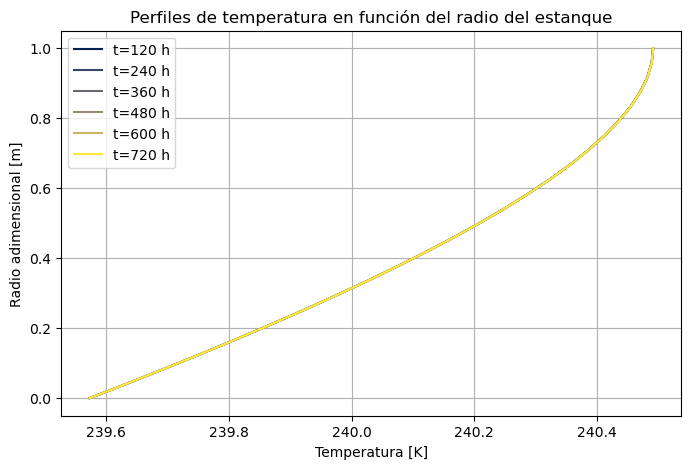

In [103]:
# Tiempos a graficar (índices correspondientes)
time_indices = jnp.arange(0, sol.ts.shape[0], int(sol.ts.shape[0]/6) )
r = jnp.linspace(0, 1, len(tanque.z_grid))
plt.figure(figsize=(8, 5))
for i, idx in enumerate(time_indices[1:]):
    plt.plot(sol.ys[idx, 1:], r, label=f"t={int(sol.ts[idx]//3600)} h", color=plt.cm.cividis(i / (len(time_indices)-2)))
plt.xlabel("Temperatura [K]")
plt.ylabel("Radio adimensional [m]")
plt.title("Perfiles de temperatura en función del radio del estanque")
plt.legend()
plt.grid(True)
plt.show()


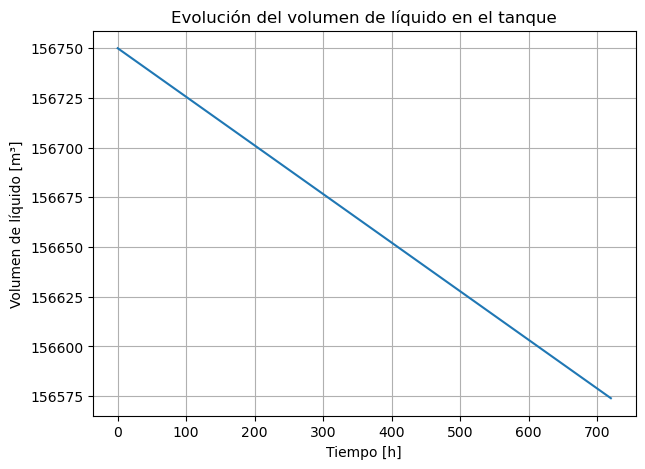

In [44]:
plt.figure(figsize=(7, 5))
plt.plot(sol.ts/3600, sol.ys[:, 0], label='Volumen de líquido')
plt.xlabel("Tiempo [h]")
plt.ylabel("Volumen de líquido [m³]")
plt.title("Evolución del volumen de líquido en el tanque")
plt.grid(True)
plt.show()

# Optimize

In [25]:
# LNG tank properties
Q_roof = 0 # Roof heat ingress / W
T_air = 298.15 # Temperature of the environment K

#V_tank = 60000 # Tank volume / m^3
V_tank = 165000 # Tank volume / m^3

a = 0.40857274020683065
d_i = ((4 * V_tank)/(jnp.pi * a))**(1/3) # internal diameter / m
# Thickness of the in % of the internal diameter
ST = 1.02
d_o = d_i * ST # external diameter / m

# Set overall heat transfer coefficient through the walls for liquid and vapour
U_L = 0.08 # 0.08 # W/m2/K
U_V = 0.08 # 0.08 # W/m2/K

# Initial liquid filling / Dimensionless
LF = 0.95 

# Specify tank operating pressure
P = 100000 # Pa

# # Initialise cryogen
cryogen = Cryogen("ammonia")

tanque = Tank(d_i, d_o, V_tank, LF, cryogen)
tank_params = make_params(tanque) # IT MUST BE CALLED BEFORE THE EVAPORATE FUNCTION WITH THE NAME "p"


In [31]:
# Configurar el optimizador Adam
lr = 1e-1
opt_init, opt_update, get_params = optimizers.adam(lr)
init_param = jnp.array(1, dtype=jnp.float64)  # Parámetro inicial para el aspecto del tanque
time_final = 720*3600                         # Tiempo final en segundos
opt_state = opt_init(init_param)              # tank, opt_state, t_f, max_iter, lr
max_iter = 100
trained_param, opt_state_save, trained_error = optimize_tank(opt_state, tank_params, time_final, max_iter, lr)


Iteration 0, Training loss: 4.7796e-05, lr: 1.0000e-01, aspect_ratio: 1.0000
Iteration 1, Training loss: 4.6666e-05, lr: 1.0000e-01, aspect_ratio: 0.9001
Iteration 2, Training loss: 4.5602e-05, lr: 1.0000e-01, aspect_ratio: 0.8004
Iteration 3, Training loss: 4.4605e-05, lr: 1.0000e-01, aspect_ratio: 0.7010
Iteration 4, Training loss: 4.3676e-05, lr: 1.0000e-01, aspect_ratio: 0.6021
Iteration 5, Training loss: 4.2815e-05, lr: 1.0000e-01, aspect_ratio: 0.5038
Iteration 6, Training loss: 4.2021e-05, lr: 1.0000e-01, aspect_ratio: 0.4064
Iteration 7, Training loss: 4.1293e-05, lr: 1.0000e-01, aspect_ratio: 0.3100
Iteration 8, Training loss: 4.0631e-05, lr: 1.0000e-01, aspect_ratio: 0.2148
Iteration 9, Training loss: 4.0034e-05, lr: 1.0000e-01, aspect_ratio: 0.1211
Iteration 10, Training loss: 3.9500e-05, lr: 1.0000e-01, aspect_ratio: 0.0290
Iteration 11, Training loss: 3.9028e-05, lr: 1.0000e-01, aspect_ratio: -0.0613
Iteration 12, Training loss: 3.8614e-05, lr: 1.0000e-01, aspect_ratio: -0

In [34]:
trained_param

Array(-0.93834081, dtype=float64)

In [35]:
0.1 + jnp.exp(-0.9392)

Array(0.49094046, dtype=float64, weak_type=True)

In [36]:
objective_function(trained_param, time_final, tank_params)

Array(3.69313169e-05, dtype=float64)

In [37]:
objective_function(0.40857274020683065, time_final, tank_params)

Array(4.20374236e-05, dtype=float64)

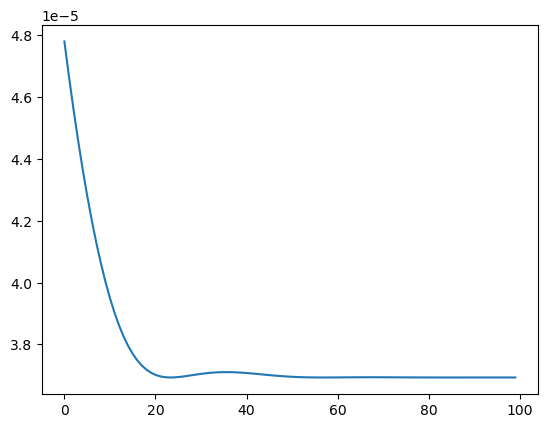

In [32]:
plt.plot(trained_error, label='Error de entrenamiento')